# Level 2 · Task 2 — Decision Trees for Classification
### Codveda Technologies — Machine Learning Internship
**Intern:** Mouhamed Diop · **ID:** CV/A1/79278

---
**Goal:** Build a decision tree to predict the **species** of iris flowers.
**Steps:** load → train → visualize the tree → prune to prevent overfitting → evaluate (accuracy, F1).
**Dataset:** `iris.csv`. **Tools:** Python, scikit-learn, pandas, matplotlib.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report
print("Libraries loaded.")

Libraries loaded.


## Step 1 — Load & Split

In [2]:
df = pd.read_csv("../../data/iris.csv")
print("Shape:", df.shape, "| Missing:", df.isnull().sum().sum())
X = df.drop(columns=["species"])
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)
df.head()

Shape: (150, 5) | Missing: 0
Train: (120, 4)  Test: (30, 4)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**Note:** decision trees don't need feature scaling — they split on thresholds, not distances.

## Step 2 — Train a Full (Unpruned) Tree
First we grow a tree without depth limits to see its natural complexity.

In [3]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)
print("Full tree depth :", full_tree.get_depth())
print("Full tree leaves:", full_tree.get_n_leaves())
print("Test accuracy   :", round(accuracy_score(y_test, full_tree.predict(X_test)), 3))

Full tree depth : 5
Full tree leaves: 8
Test accuracy   : 0.933


## Step 3 — Prune the Tree (max_depth=3)
A shallower tree generalizes better and is easier to read. We cap depth at 3 to **prevent
overfitting**.

In [4]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
print("Pruned depth    :", tree.get_depth())
print("Test accuracy   :", round(accuracy_score(y_test, y_pred), 3))

Pruned depth    : 3
Test accuracy   : 0.967


## Step 4 — Visualize the Tree
Each node shows the split rule, Gini impurity, sample counts, and predicted class.

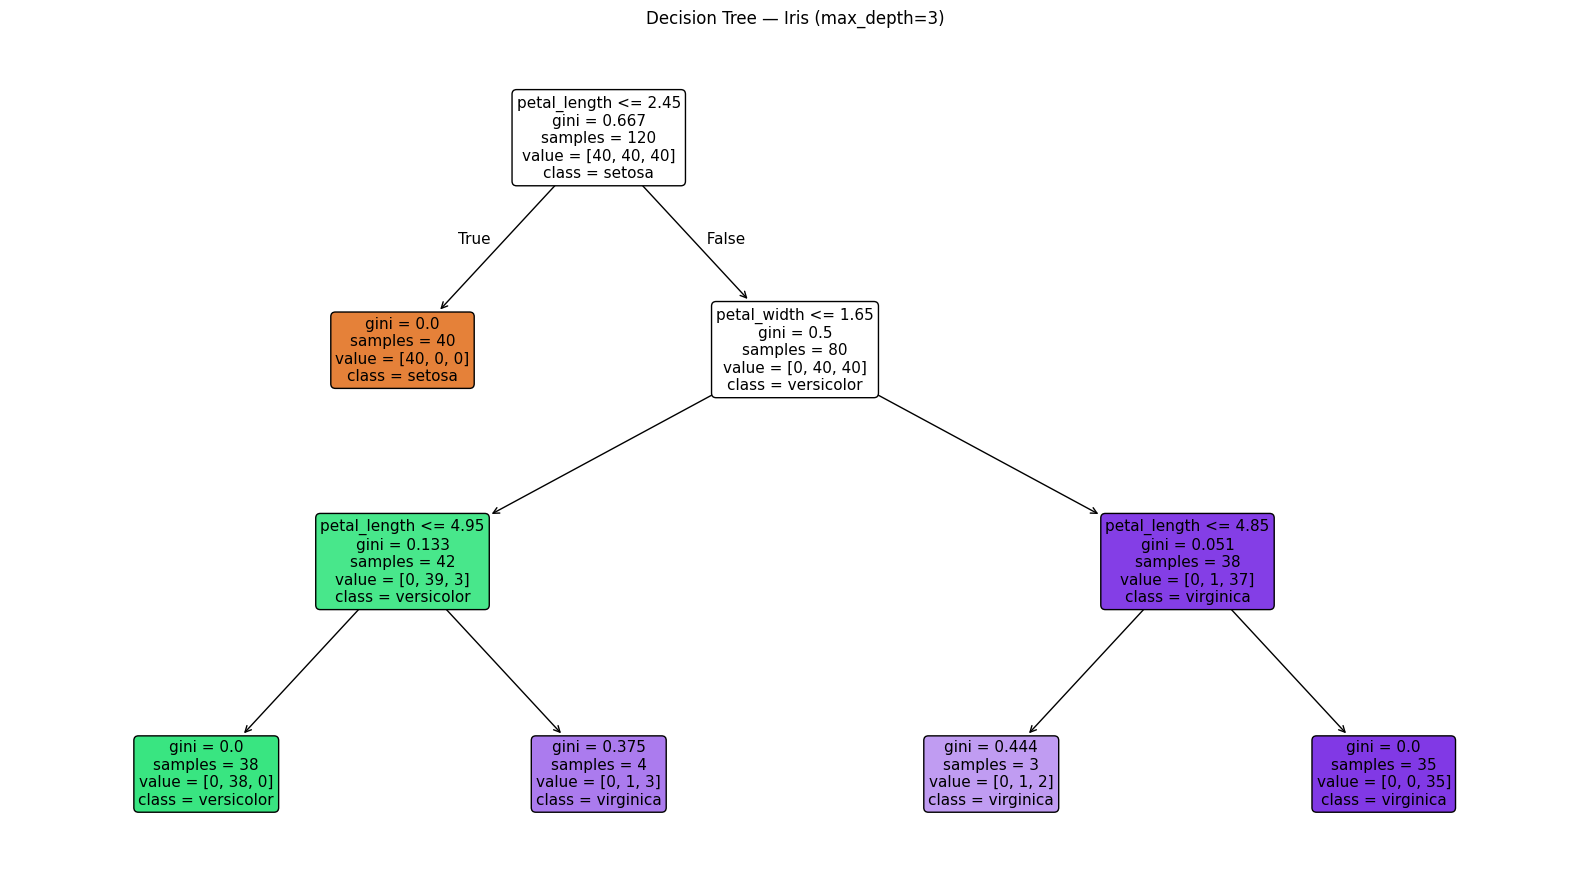

In [5]:
plt.figure(figsize=(16,9))
plot_tree(tree, feature_names=X.columns, class_names=tree.classes_,
          filled=True, rounded=True, fontsize=11)
plt.title("Decision Tree — Iris (max_depth=3)")
plt.tight_layout()
plt.savefig("output_decision_tree.png", dpi=110)
plt.show()

**Reading it:** the tree first splits on `petal_length`/`petal_width` — these features
separate the three species almost perfectly.

## Step 5 — Evaluate (Accuracy & F1) + Feature Importance

Accuracy      : 0.967
F1-score (macro): 0.967

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



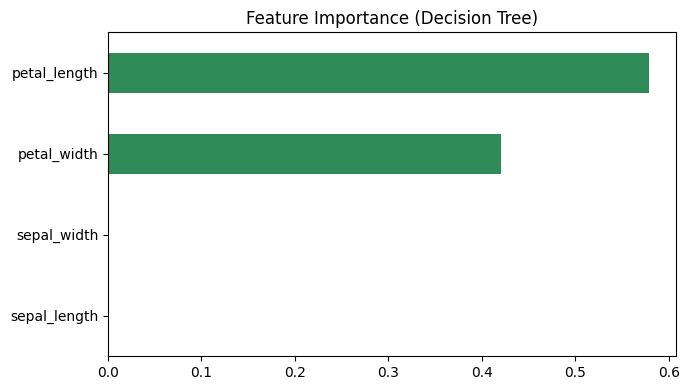

In [6]:
print(f"Accuracy      : {accuracy_score(y_test, y_pred):.3f}")
print(f"F1-score (macro): {f1_score(y_test, y_pred, average='macro'):.3f}\n")
print(classification_report(y_test, y_pred))

importances = pd.Series(tree.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(7,4))
importances.plot.barh(color="seagreen")
plt.title("Feature Importance (Decision Tree)")
plt.tight_layout()
plt.savefig("output_feature_importance.png", dpi=110)
plt.show()

**Reading it:** petal measurements dominate the decisions; sepal features contribute little.

## Summary
| Item | Result |
|------|--------|
| Model | Decision Tree (pruned, max_depth=3) |
| Accuracy | ~0.97 |
| F1 (macro) | ~0.97 |
| Key features | petal_length, petal_width |

Pruning keeps the tree simple and interpretable while maintaining high accuracy.
✅ **Level 2 · Task 2 complete.**